# Comparing DDA scores — v1 vs v2

Joins `IxIDN_ORDON_benchmark_DDA_v1.csv` and `..._v2.csv` on `ID`, attaches the
IxIDN/ORDON provenance flags, and asks what actually changed and whether it moved the
separation metrics.

All logic lives in [`dda_analysis.py`](dda_analysis.py).

In [1]:
import dda_analysis as da

da.apply_style()

cmp = da.load_versions("IxIDN_ORDON_benchmark_DDA_v1.csv",
                       "IxIDN_ORDON_benchmark_DDA_v2.csv",
                       label_a="v1", label_b="v2")
cmp.head()

,ID,d1_disease_label,d2_disease_label,v1,v2,exist_IxIDN,exist_ORDON,delta,group
0,0,Myasthenia gravis,AL amyloidosis,0.2363,0.2363,True,False,0.0,IxIDN
1,1,Burkitt lymphoma,Szary syndrome,0.4545,0.4545,True,False,0.0,IxIDN
2,2,MALT lymphoma,"Primary dystonia, DYT4 type",0.1535,0.1535,False,True,0.0,ORDON
3,3,Neurotrophic keratopathy,Early-onset generalized limb-onset dystonia,0.1628,0.1628,False,True,0.0,ORDON
4,4,Idiopathic/heritable pulmonary arterial hypert...,Systemic-onset juvenile idiopathic arthritis,0.4341,0.4341,True,False,0.0,IxIDN


## 1. How much changed?

In [2]:
da.version_diff_summary(cmp)

,bucket,rows,pct
0,rows total,10336,100.000
1,identical v1 == v2,10325,99.894
2,changed,11,0.106
3,changed ↓ (revised down),11,0.106
4,changed ↑ (revised up),0,0.000


In [3]:
changed = cmp.loc[cmp.v1 != cmp.v2].sort_values("delta")
print(f"changed rows by group:\n{changed['group'].value_counts().to_string()}\n")
changed[["ID", "d1_disease_label", "d2_disease_label", "group", "v1", "v2", "delta"]]

changed rows by group:
group
IxIDN    11



,ID,d1_disease_label,d2_disease_label,group,v1,v2,delta
6135,6200,Polyneuropathy associated with IgM monoclonal ...,Chronic inflammatory demyelinating polyneuropathy,IxIDN,0.2499,0.1980,-0.0519
4649,4693,Polyneuropathy associated with IgM monoclonal ...,polymyositis,IxIDN,0.1669,0.1543,-0.0126
7784,7855,Polyneuropathy associated with IgM monoclonal ...,Polyarteritis nodosa,IxIDN,0.1659,0.1540,-0.0119
9661,9745,Polyneuropathy associated with IgM monoclonal ...,Primary biliary cholangitis,IxIDN,0.1659,0.1540,-0.0119
2200,2217,Polyneuropathy associated with IgM monoclonal ...,Waldenstrom macroglobulinemia,IxIDN,0.1653,0.1537,-0.0116
7172,7243,Polyneuropathy associated with IgM monoclonal ...,Granulomatosis with polyangiitis,IxIDN,0.1649,0.1536,-0.0113
9267,9350,Polyneuropathy associated with IgM monoclonal ...,Mucous membrane pemphigoid,IxIDN,0.1649,0.1536,-0.0113
5570,5627,Polyneuropathy associated with IgM monoclonal ...,Immunoglobulin A vasculitis,IxIDN,0.1643,0.1534,-0.0109
9732,9817,Polyneuropathy associated with IgM monoclonal ...,microscopic polyangiitis,IxIDN,0.1643,0.1534,-0.0109
7226,7297,Polyneuropathy associated with IgM monoclonal ...,Giant cell arteritis,IxIDN,0.1774,0.1678,-0.0096


## 2. Which rows moved, and by how much

A dumbbell chart is the right form here: only a handful of rows move, and both the
before/after values and the size of the shift matter.

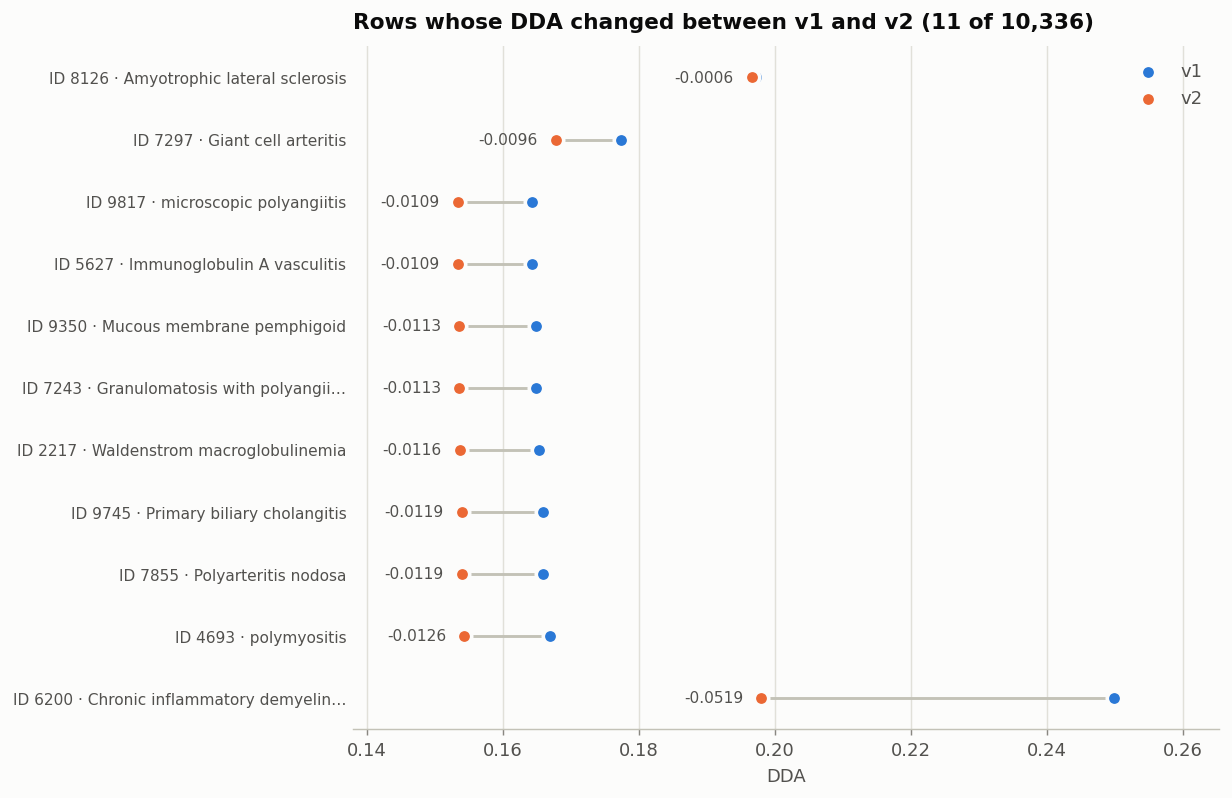

In [4]:
da.plot_version_changes(cmp)

## 3. Did it move the metrics?

AUC and Wasserstein recomputed independently for each version, on the same
IxIDN-positive / ORDON-negative split.

In [5]:
da.version_metrics(cmp)

,AUC,best threshold,TPR@best,FPR@best,W1,W1 (pooled SD),mean IxIDN,mean ORDON,dominance
v1,0.82733,0.2745,0.683352,0.154462,0.153284,1.267896,0.36098,0.207696,True
v2,0.827169,0.2745,0.683352,0.154462,0.153255,1.267424,0.360951,0.207696,True
delta,-0.000161,0.0,0.0,0.0,-0.000029,-0.000471,-0.000029,0.0,


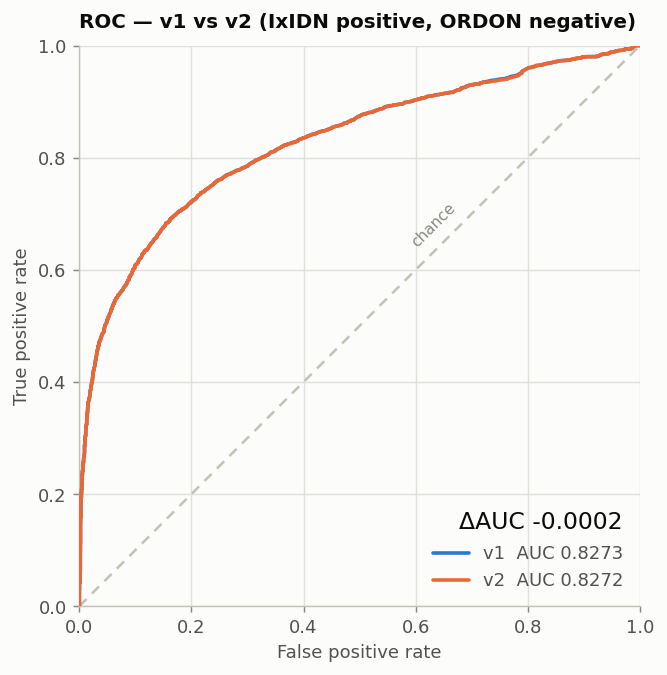

In [6]:
da.plot_version_roc(cmp)

## 4. Distributions side by side

Each version's positive and negative distribution, with both Wasserstein distances in
the title.

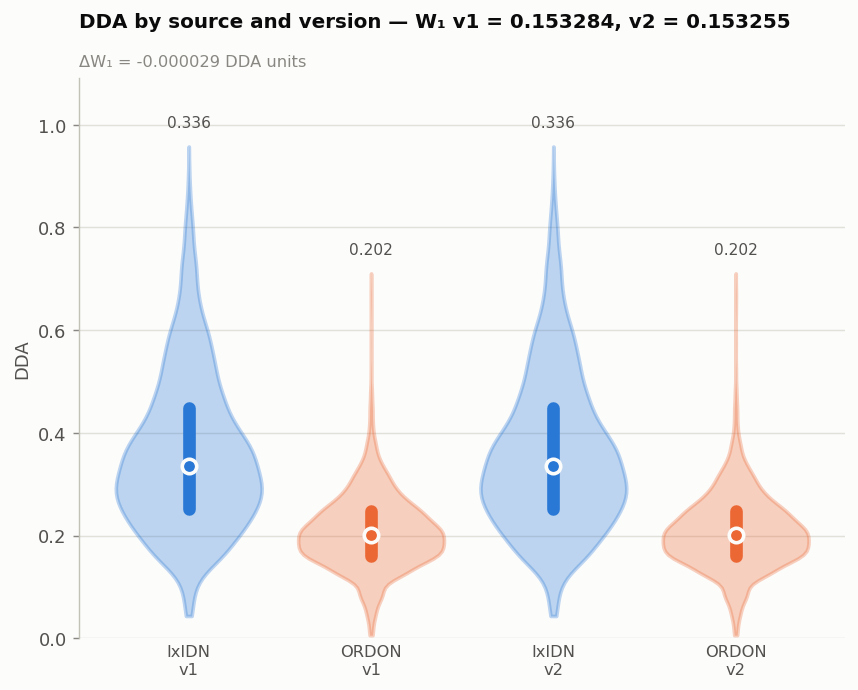

In [7]:
da.plot_version_violin(cmp)